#Text and Media Analytics (INFOMTMA)

## Midterm Take-Home Exam

### Deadline: Monday December 15 2025, 9:00

The midterm take-home exam for the Text and Media Analytics course consists of **two assignments** with six questions in total that require you to write working code blocks that produce results, and to write a discussion of the results. Each answer is evaluated on the quality of the code or code edits (as far as you were asked to write new code), whether the required results are produced, and the quality of the discussion, where applicable. Make sure your code is clearly structured and properly signposted. Explain via commenting each step. The scores for the questions add up to 100, with scores per question indicated next to the header of the question.

Please submit your Jupyter notebook file (`.ipynb`) via Brightspace. Do not submit a link to a Google Colab -- but keep in mind that your notebooks should run on the Colab, because that is how we will evaluate it.

# Exercise 1: Text analysis (70 points total)

All questions in this exercise deal with the Patronizing and condescending language detection dataset (https://sites.google.com/view/pcl-detection-semeval2022/). This dataset features paragraphs that are extracted from news articles from a range of outlets, which may contain one or more instances of patronizing or condenscending language targeting a set of predefined vulnerable communities. To know more about these data, you can check the link to the dataset.

Let's start by loading the data:

In [ ]:
import pandas as pd

! wget https://gist.githubusercontent.com/fkunneman/c0ef16b0052f1c2414683dd1d30c960a/raw/01deb36cca06ed13e0c613513353c5ea6337a1c4/dontpatronizeme_pcl.tsv

df = pd.read_csv('dontpatronizeme_pcl.tsv',delimiter='\t',header=None)
df.head()

--2025-12-13 22:52:06--  https://gist.githubusercontent.com/fkunneman/c0ef16b0052f1c2414683dd1d30c960a/raw/01deb36cca06ed13e0c613513353c5ea6337a1c4/dontpatronizeme_pcl.tsv
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3122005 (3.0M) [text/plain]
Saving to: ‘dontpatronizeme_pcl.tsv.1’

dontpatronizeme_pcl 100%[===================>]   2.98M  --.-KB/s    in 0.01s   

2025-12-13 22:52:07 (274 MB/s) - ‘dontpatronizeme_pcl.tsv.1’ saved [3122005/3122005]



,0,1,2,3,4,5
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0


More information about the data can be seen in the readme:

In [ ]:
! wget https://gist.githubusercontent.com/fkunneman/2de27cdcd7160a80c3b0482ffd793cbd/raw/23917b9ecbd651150499f08223f8692dd7ede798/README_training.txt

with open('README_training.txt','r',encoding='utf-8') as file_in:
  print(file_in.read())

--2025-12-04 23:39:41--  https://gist.githubusercontent.com/fkunneman/2de27cdcd7160a80c3b0482ffd793cbd/raw/23917b9ecbd651150499f08223f8692dd7ede798/README_training.txt
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5302 (5.2K) [text/plain]
Saving to: ‘README_training.txt’

README_training.txt 100%[===================>]   5.18K  --.-KB/s    in 0s      

2025-12-04 23:39:41 (90.5 MB/s) - ‘README_training.txt’ saved [5302/5302]

					######################## SEMEVAL 2022 INFORMATION ###########################
					# If you are participating on SemEval 2022-Task 4, this is the training     #
					# set provided for the task (there are no trial and no dev sets provided).  #
					# The full test set can be made avaiable upon request after SemEval 2022    #
	

### Question 1: Exploration (20 points)

First, do an exploratory analysis:

1) (6 points) What are the labels and what do they mean? Transform these labels into a binary labeling, as advised in the README. Then start analyzing frequencies and associations:
  - 1: How many instances are there per label?
  - 2: What is the distribution of keywords (the 3rd column, see readme)?
  - 3: What is the relation between the keyword column and binary labels? In other words: are certain keywords particularly associated with one of the two labels? How do you interpret these numbers?

2) (7 points) Compare both labels in the following way: print out the 10 most used adjectives, 10 most used adverbs and 10 most used verbs in both categories and reflect on whether these lists tell us anything insightful about each of the categories and the distinction between them. Discuss the limitations of these insights as well. What additional analyses would be needed for more insightful results?

3) (7 points) Now analyze the textual messages (the text column). You can choose the characteristic that you analyze yourself. What do you observe? Motivate why this helps to better understand the data, also with respect to the potential of / choice for a machine learning classifier.


The written answers combined should not exceed 350 words in total. For each of the subquestions, also support these with code.


### Question 1 - Answers

### Question 1.1

The labels were converted into a binary variable, where 0 = No PCL (labels 0 and 1), and 1 = PCL (labels 2, 3, 4).
The distribution is very imbalanced, with PCL being rare. Specifically, in the Non-PCL group, 8529 cases are labelled with 0 and 947 with 1. Within the PCL group, 144 cases are labelled with 2, 458 with 3 and finally 391 with 4.

The most frequent words are migrant, in-need and vulnerable, with counts between 909-1089, showing that there is not any targeted group.

The words to associate the most with PCL (16%) are homeless, poor-families, in-need. Words like migrant and immigrant associate much less (2-3%), so they might be treated more neutraly.

### Question 1.2

**Adjectives**

The PCL group's top adjectives include poor, homeless, disabled, vulnerable, hopeless, young, words that could be characterised by weakness/disadvantage. It also includes neutral adjectives (many, other, more, new). Meanwhile, the Non-PCL group shares similar POS vocabulary, but has slightly higher counts of neutral adjectives, which could indicate more neutral framing.

**Adverbs**

The adverbs (also, so, even, etc.) are highly similar in both groups, so in this case, I do not think they can be used as indicators of possibly patronizing tone.

**Verbs**

Similarly to the adverbs, the verbs (say, have, make, etc.) are also shared within the groups, so the differences are minor.

Overall, the differences are subtle. We are not aware of the context of the words, as POS frequencies ignore sentiment. An insightful analysis would consider context, how words are used together, and sentiment, not just word types.

### Question 1.3
I investigated the sentiment polarity of the texts, to explore the emotional tone between the groups. The PCL texts have a slightly higher average polarity (0.041) than the Non-PCL (0.020). This indicates that PCL has a slighlty more positive/sympathetic tone, meaning target groups could be treated with pity and compassion. However, the distributions almost overlap, so the effect is small and sentiment alone proved insufficient for classification. Practically, sentiment polarity could be included as a low weight feature along embeddings or TF-IDF.

label
0    8529
1     947
2     144
3     458
4     391
Name: count, dtype: int64




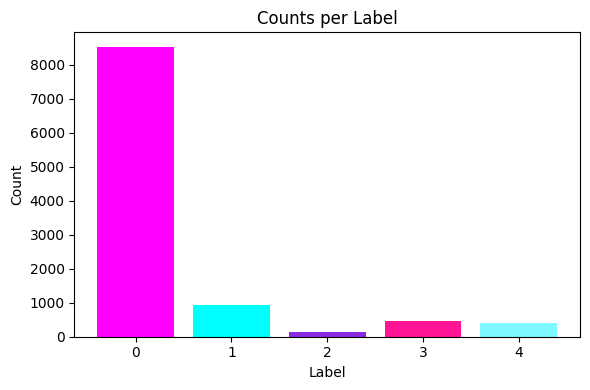

Most frequent keywords: 
keyword
migrant          1089
in-need          1082
vulnerable       1080
homeless         1077
women            1070
refugee          1068
immigrant        1061
disabled         1028
hopeless         1005
poor-families     909
Name: count, dtype: int64




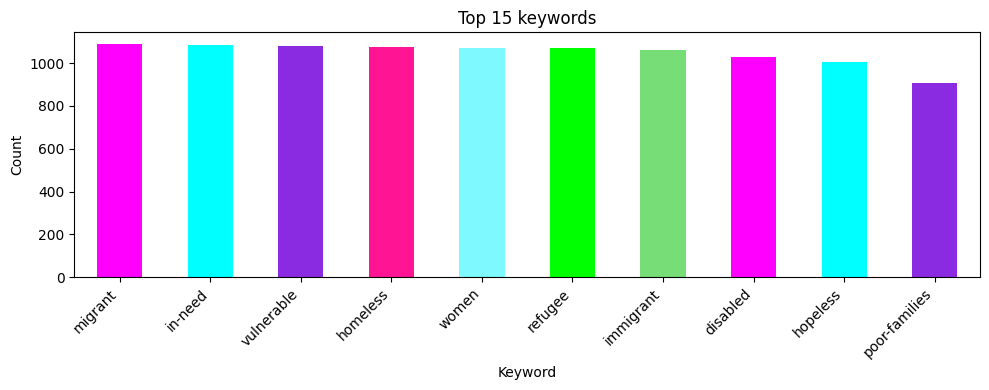

Keywords ranked by likelihood of patronizing language: 
keyword
homeless         0.165274
poor-families    0.165017
in-need          0.162662
hopeless         0.123383
refugee          0.080524
disabled         0.078794
vulnerable       0.074074
women            0.048598
migrant          0.033058
immigrant        0.028275
Name: binary_label, dtype: float64


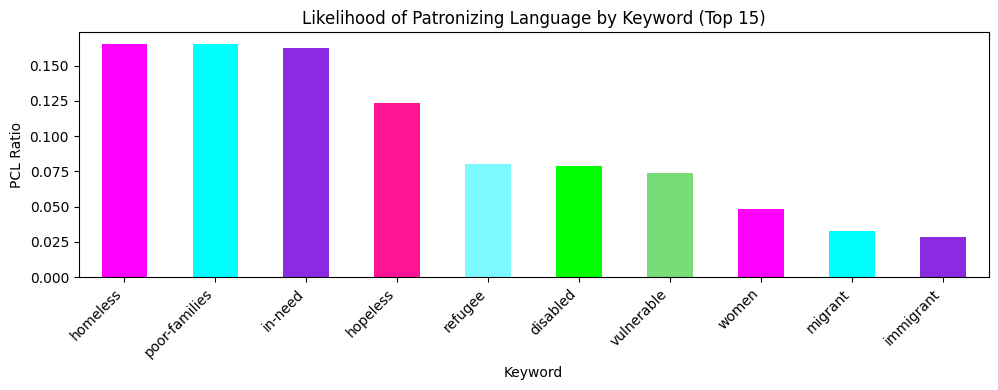

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# * Question 1.1.1: Instances per Label
# Adding the column names
df.columns = ["par_id", "art_id", "keyword", "country", "text", "label"]

# Converting the labels according to the README by creating a function
def convert_label(x):
  return 0 if x in [0,1] else 1

#Apply the function to the label column, to create a new column "binary_label"
df["binary_label"] = df["label"].apply(convert_label)

# Count how many items per label with value_counts(), and then sort the labels numerically
label_counts = df["label"].value_counts().sort_index()
print(label_counts)
print("\n")

# Bar chart of label counts

# Defining some colors using hex codes
colors = ["#FF00FF", "#00FFFF", "#8A2BE2", "#FF1493", "#7DF9FF", "#00FF00", "#77DD77"]

plt.figure(figsize = (6, 4)) # adjusting width and height to my liking

# Will plot each label as a bar and take only as many colors as we need
bars = plt.bar(
    label_counts.index.astype(str), # converting numeric labels to strings for the x axis
    label_counts.values, # counts for each label
    color = colors[:len(label_counts)] # slice from the color list
    )
plt.title("Counts per Label")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout() # ensuring no overlaps
plt.show()

# * Question 1.1.2: Counting Most Frequent Keywords
# This helps us see which groups occur most in the data
keyword_counts = df["keyword"].value_counts()
print("Most frequent keywords: ")
print(keyword_counts.head(15)) # showing the top 15
print("\n")

# Plot
plt.figure(figsize = (10, 4))
keyword_counts.head(15).plot(kind = "bar", color = colors[:15])
plt.title("Top 15 keywords")
plt.xlabel("Keyword")
plt.ylabel("Count")
plt.xticks(rotation = 45, ha = "right") # rotating the labels so they don't overlap
plt.tight_layout()
plt.show()


# * Question 1.1.3: Relationship between Keywords and PCL
# Here I will inspect the relationship between the keywords and the patronizing labels
# E.g. will check for each keyword, what percentage of times does it come with a PCL
# Will group the data by keyword, then the mean of 0/1 values gives the proportion PCL
keyword_pcl_ratio = df.groupby("keyword")["binary_label"].mean().sort_values(ascending=False)
print("Keywords ranked by likelihood of patronizing language: ")
print(keyword_pcl_ratio)

# Plot
plt.figure(figsize = (10, 4))
keyword_pcl_ratio.head(15).plot(kind = "bar", color = colors[:15])
plt.title("Likelihood of Patronizing Language by Keyword (Top 15)")
plt.xlabel("Keyword")
plt.ylabel("PCL Ratio")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()


In [ ]:
# * Question 1.2: POS Analysis using spaCy
# Will use spaCy
import spacy
from collections import Counter
import random

# I will load the default small english NLP model
# Includes tokenization, POS tagging, lemmatization
nlp = spacy.load("en_core_web_sm")

# The entire dataset is huge, and will be very time consuming to run spacy on all of it, I will use random subsamples
# Creating group 1 (PCL, label = 1)
pcl_texts = df[df["binary_label"] == 1]["text"].tolist()

# Creating group 2 (NON-PCL, label = 0)
non_pcl_texts = df[df["binary_label"] == 0]["text"].tolist()

# Setting a random small sample size because tha dataset is really large
sample_size = 1300

# Using 'random.sample()' which chooses a random subset without replacement. Will therefore create two subsamples
# Also use min() to make sure we don't sample more than available
pcl_sample = random.sample(pcl_texts, min(len(pcl_texts), sample_size))
non_pcl_sample = random.sample(non_pcl_texts, min(len(non_pcl_texts), sample_size))

# Will create a function to extract POS types (following the method from seminar 2)
def extract_pos_counts(text_list):

  # Return counters for adjectives, adverbs and verbs, using the POS tagging from spaCy.

  # Creating empty counters for each POS category
  adj_counter = Counter()
  adv_counter = Counter()
  verb_counter = Counter()

  # Loop through each text
  for par in text_list:
    # Sending the text through the spaCy model
    doc = nlp(par)

    # Then loop through each token in the processed text and check the POS tag that it has
    for token in doc:

      # For adjectives
      if token.pos_ == "ADJ":
        adj_counter[token.lemma_.lower()] += 1 # using lemma to reduce variation

      # For adverbs
      elif token.pos_ == "ADV":
        adv_counter[token.lemma_.lower()] += 1

      # For adverbs
      elif token.pos_ == "VERB":
        verb_counter[token.lemma_.lower()] += 1

  return adj_counter, adv_counter, verb_counter

# Now we will apply the function to both groups
pcl_adj, pcl_adv, pcl_verb = extract_pos_counts(pcl_sample)
non_pcl_adj, non_pcl_adv, non_pcl_verb = extract_pos_counts(non_pcl_sample)

# Finally, printing the 10 most frequent words
print("Top 10 Adjectives - PCL:")
print(pcl_adj.most_common(10))
print("\n")
print("Top 10 Adjectives - NON PCL:")
print(non_pcl_adj.most_common(10))
print("\n")
print("Top 10 Adverbs - PCL:")
print(pcl_adv.most_common(10))
print("\n")
print("Top 10 Adverbs - NON PCL:")
print(non_pcl_adv.most_common(10))
print("\n")
print("Top 10 Verbs - PCL:")
print(pcl_verb.most_common(10))
print("\n")
print("Top 10 Verbs - NON PCL:")
print(non_pcl_verb.most_common(10))




Top 10 Adjectives - PCL:
[('poor', 242), ('homeless', 174), ('disabled', 100), ('vulnerable', 94), ('many', 92), ('hopeless', 79), ('other', 73), ('more', 70), ('young', 49), ('new', 48)]


Top 10 Adjectives - NON PCL:
[('vulnerable', 152), ('disabled', 148), ('poor', 143), ('homeless', 124), ('more', 102), ('many', 83), ('other', 81), ('illegal', 66), ('high', 66), ('new', 61)]


Top 10 Adverbs - PCL:
[('also', 80), ('so', 78), ('even', 62), ('very', 56), ('just', 51), ('more', 49), ('now', 47), ('well', 45), ('most', 44), ('only', 43)]


Top 10 Adverbs - NON PCL:
[('also', 142), ('so', 80), ('even', 66), ('more', 65), ('only', 64), ('most', 56), ('just', 53), ('now', 52), ('well', 49), ('still', 46)]


Top 10 Verbs - PCL:
[('say', 243), ('have', 204), ('help', 159), ('give', 135), ('make', 106), ('do', 95), ('come', 89), ('live', 82), ('provide', 81), ('get', 80)]


Top 10 Verbs - NON PCL:
[('say', 341), ('have', 218), ('make', 121), ('come', 92), ('go', 77), ('take', 76), ('be', 72)

Average sentiment per label: binary_label
0    0.020032
1    0.040497
Name: sentiment, dtype: float64


<Figure size 600x400 with 0 Axes>

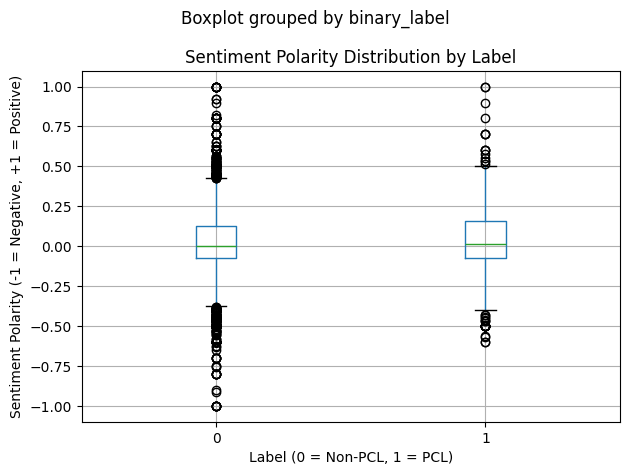

In [ ]:
# * Question 1.3: Text Feature Chosen: Sentiment Polarity
# This feature will show us how positive or negative our text is, using textblob
from textblob import TextBlob
import matplotlib.pyplot as plt

df["text"] = df["text"].fillna("").astype(str)

# Computing sentiment polarity for every text in the dataset
# Then applying textblob to each row of the text column, and store the result in the new sentiment column
df["sentiment"] = df["text"].apply(lambda x: TextBlob(x).sentiment.polarity)

# Will inspect the average sentiment for the PCL and NON-PCL group to compare them
means = df.groupby("binary_label")["sentiment"].mean()
print("Average sentiment per label:", means)

# Plot
plt.figure(figsize = (6, 4))
df.boxplot(column = "sentiment", by = "binary_label")
plt.title("Sentiment Polarity Distribution by Label")
plt.xlabel("Label (0 = Non-PCL, 1 = PCL)")
plt.ylabel("Sentiment Polarity (-1 = Negative, +1 = Positive)")
plt.tight_layout()
plt.show()



## Question 2: Classification (30 points)

Here, you will use a classifier to distinguish between the five levels of patronizing language in a newsreport. The task is to distinguish between the labels 0 to 4 (so not the binary labels that were analyzed in question 1).

The assignment is structured in the following way:

1. (12 points) Train two multi-class classifiers of your choice.
2. (6 points) Introduce a baseline classifier to compare your classifiers to.
3. (6 points) Choose and motivate the metrics you will use for performance evaluation.
4. (6 points) Compare the performance of your classifiers to the baseline and to each other.

The higher the performance of your classifiers (given the resources), the better! The more different your classifiers are, the better -- think of Transformer-based classifiers, models based on static word embeddings, tf-idf-based solutions and whatever else comes to your mind. Don't forget to evaluate on test data -- perform a ``train-test`` split. Don't exceed 200 words (non-code) in answering this question.

### Question 2 - Answers

I trained two multi-class classifiers to predict the five levels (labels 0-4) of PCL.

The first model is a TF-IDF representation which captures important unigrams and bigrams, combined with a Linear Support Vector Machine classifier, which is supposed to be good for sparse text data. This model achieved Accuracy = 0.77 and Macro-F1 = 0.30.

The second model is a fine-tuned DistilBERT transformer. I used a weighted sampler to address class imbalance. Initially I tried to oversample the minority class (PCL), but it doubled the runtime and did not improve results much. I also added a validation split, early stopping, and a learning rate scheduler to avoid overfitting. On the final test set, the best Accuracy = 0.77 and Macro-F1 = 0.39, which is the highest across both models. However due to the random weighted sampling and dropout, there is small variation between runs of approximately -+0.02.

The third baseline model is a majority class classifier, which performs poorly on minority classes, due to the imbalanced data, where PCL is rare, with an Accuracy = 0.81 and Macro-F1 = 0.18.

Overall, DistilBERT performed the best, but TF-IDF was faster and competitive.

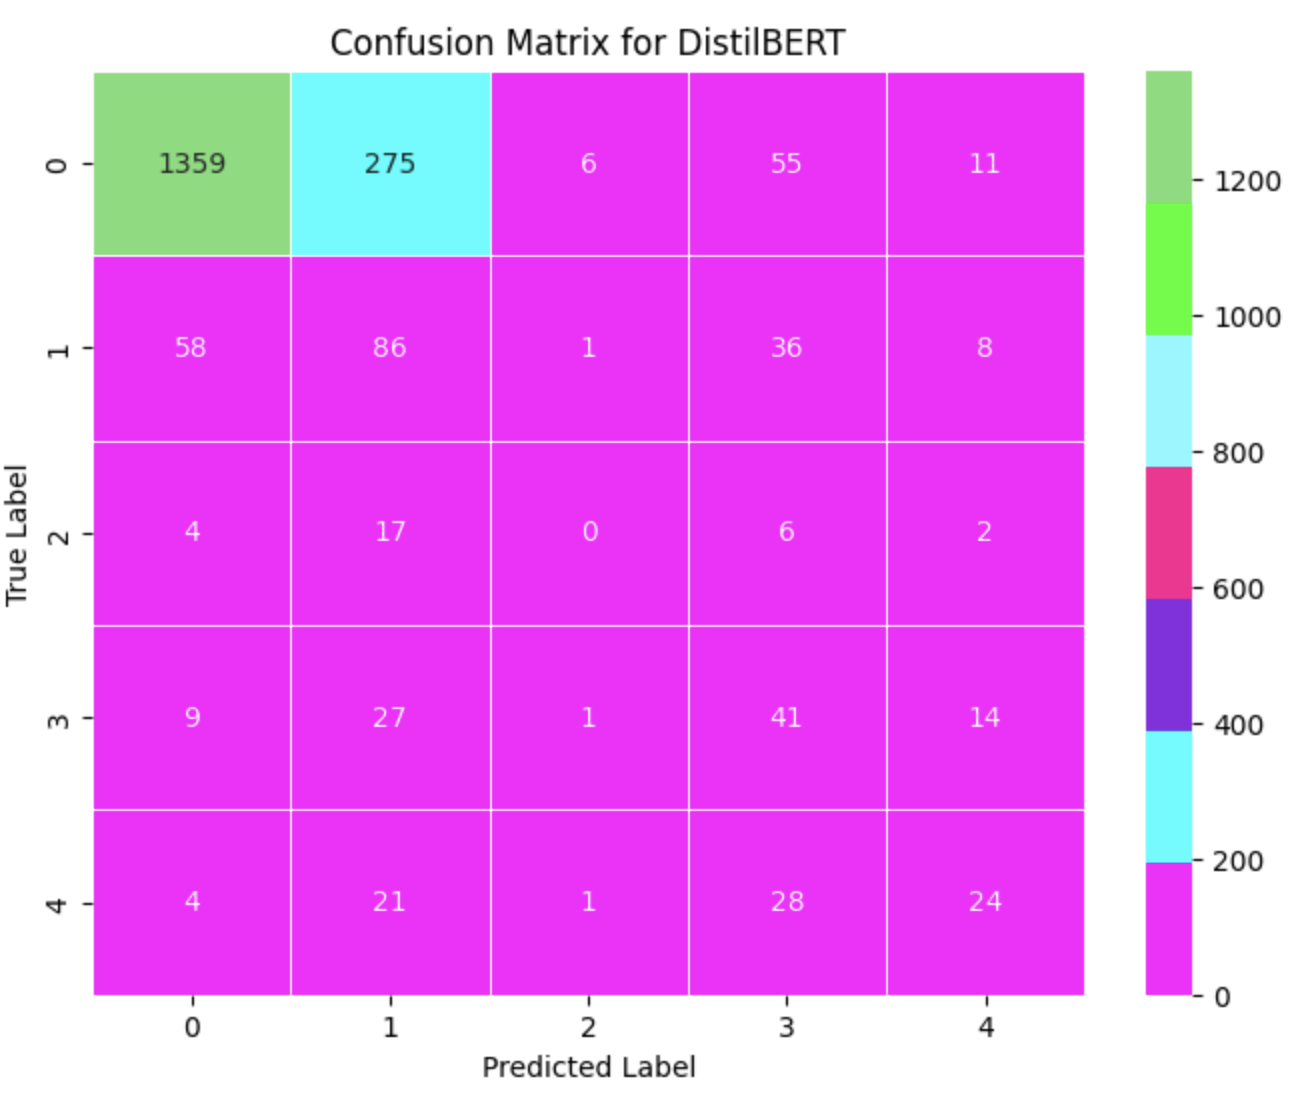

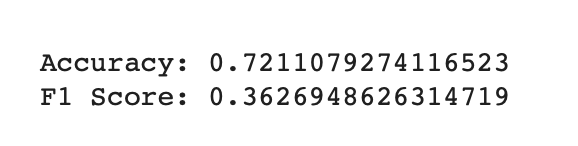

In [ ]:
# *Question 2.1
# Classifier 1: TF-IDF & Linear Support Vector Machine

# Importing the necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.svm import LinearSVC
import spacy
import numpy as np

# Preparing the data
df = df.dropna(subset = ["text"]) # dropping rows where the text is missing, cause otherwise we cannot vectorize them,
X = df["text"] # X contains the "raw" text (input)
y = df["label"] # y contains the numerical class labels 0-4

# 80% train, 20% test split, stratify=y keeps our class proportions similar in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# TF-IDF converts text into numeric features
tfidf = TfidfVectorizer(
    lowercase = True, # lowercases all words
    ngram_range = (1,2), # specifying this range to use unigrams and bigrams because they can capture some short phrases
    min_df = 5, # ignore words that appear in fewer than 5 docs
    max_df = 0.9, # ignore words that appear in more than 90% of the docs
    stop_words = "english" # removing english stopwords
)

# Will fit TF-IDF on the training set only to avoid data leakage
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test) # here only transform needed, no fit

# Train the classifier, Linear SVM
# Will use LinearSVC, and setting class weight to balanced helps with the imbalances in the classes
classifier_tfidf = LinearSVC(
    C = 1.0,
    class_weight = "balanced",
)
classifier_tfidf.fit(X_train_tfidf, y_train) # here the model learns patterns in the training data

# Evaluation
# Using the trained model to predict labels for the new, unseen test data
y_pred_tfidf = classifier_tfidf.predict(X_test_tfidf)

# Accuracy score (percentage of correct predictions)
classifier_tfidf_ac = accuracy_score(y_test, y_pred_tfidf)

# Then the F1 score (gives equal weight to all classes)
classifier_tfidf_f1 = f1_score(y_test, y_pred_tfidf, average = "macro")

print("The results of the classifier TF-IDF + LINEAR SVM are:")
print("\n")
print("Accuracy:", classifier_tfidf_ac)
print("\n")
print("F1 Score:", classifier_tfidf_f1)
print("\n")

# Per label metrics
print("Classification Report for TF-IDF + LINEAR SVM:")
print(classification_report(y_test, y_pred_tfidf, digits = 3))

The results of the classifier TF-IDF Logistic Regression are:


Accuracy: 0.7717287488061128


F1 Score: 0.3054288107240024


Classification Report for TF-IDF + LINEAR SVM:
              precision    recall  f1-score   support

           0      0.877     0.907     0.892      1706
           1      0.206     0.206     0.206       189
           2      0.100     0.034     0.051        29
           3      0.194     0.141     0.164        92
           4      0.242     0.192     0.214        78

    accuracy                          0.772      2094
   macro avg      0.324     0.296     0.305      2094
weighted avg      0.752     0.772     0.761      2094



Using device; cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch 1 / 6
Training loss: 0.6005672216415405
Validation F1: 0.3287710432344892
New best model saved.

Epoch 2 / 6
Training loss: 0.010951060801744461
Validation F1: 0.3052696641245979

Epoch 3 / 6
Training loss: 0.006258057896047831
Validation F1: 0.3234552316747165
Early stopping triggered!

Loaded best model (Validation F1): 0.3287710432344892
The DistilBERT Fine Tuning results are:


Accuracy: 0.7211079274116523
F1 Score: 0.3626948626314719


Classification Report for DistilBERT:
              precision    recall  f1-score   support

           0      0.948     0.797     0.866      1706
           1      0.202     0.455     0.280       189
           2      0.000     0.000     0.000        29
           3      0.247     0.446     0.318        92
           4      0.407     0.308     0.350        78

    accuracy                          0.721      2094
   macro avg      0.361     0.401     0.363      2094
weighted avg      0.816     0.721     0.757      2094



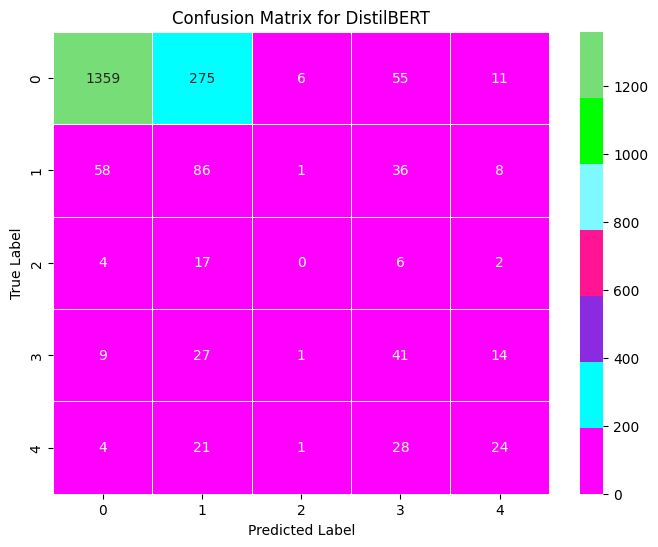

In [ ]:
# * Question 2.1
# Classifier 2: DistilBERT Fine Tuning with Weighted Sampling and Early Stopping

# Imports
import torch
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import (DistilBertTokenizer, DistilBertForSequenceClassification, get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device;", device)

# Dataset class: This class wraps the text and label into PyTorch format
# So, each item is returned in a dictionary with the input ids, attention masks and labels so that the DataLoader can use it easily
class NewsDataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_length = 96):
    self.texts = texts # list of strings
    self.labels = labels # list of integers
    self.tokenizer = tokenizer # the bert tokenizer
    self.max_length = max_length

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, idx):

    # Will tokenize 1 text at a time
    enc = self.tokenizer(
        self.texts[idx],
        truncation = True, # cutting off long sentences
        padding = "max_length", # pad shorter ones to same length
        max_length = self.max_length,
        return_tensors = "pt" # return PyTorch tensors
    )

    return{
        "input_ids" : enc["input_ids"].squeeze(0), # remove extra batch dimension
        "attention_mask" : enc["attention_mask"].squeeze(0),
        "labels" : torch.tensor(self.labels[idx], dtype = torch.long)
    }

# Prepare the data (train for learning /val for early stopping /test for final evaluation)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    X_train.tolist(),
    y_train.tolist(),
    test_size = 0.1, # 10% validation (the goal is to detect overfitting, but do not want to use too much and waste training data..)
    random_state = 42, # fix seed so the split is always the same
    stratify = y_train
)

test_texts = X_test.tolist()
test_labels = y_test.tolist()

# Create the datasets
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

train_dataset = NewsDataset(train_texts, train_labels, tokenizer)
val_dataset = NewsDataset(val_texts, val_labels, tokenizer)
test_dataset = NewsDataset(test_texts, test_labels, tokenizer)

# We have very imbalanced data. Will deal with it by using the weighted sampler
# Compute class frequencies
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts # rare classes get high weight

# Match weight to each training sample
sample_weights = [class_weights[label] for label in train_labels]

# The weighted sampler basically forces the training to focus on the minority classes
sampler = WeightedRandomSampler(
    weights = sample_weights,
    num_samples = len(train_labels),
    replacement = True
    )

# Training loader is using of course the weighted sampler
train_loader = DataLoader(train_dataset, batch_size = 16, sampler = sampler)

# Val and test loaders just use normal shuffling
val_loader = DataLoader(val_dataset, batch_size = 32)
test_loader = DataLoader(test_dataset, batch_size = 32)

# Loading Distilbert model and moving it to GPU
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels = 5)
model.to(device)

# Optimizer and scheduler
epochs = 6 # experimenting with different nr of epochs

# Usinf AdamW as it is best when using transformers
optimizer = AdamW(model.parameters(), lr = 2e-5) # tried out different lrs (5e-5, 1e-5), 2e-5 gives the best F1 measure

# The scheduler will reduce the learning rate little by little
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps = 0, num_training_steps = total_steps)

# Early stopping setup
best_val_f1 = 0
patience = 2 # allowing 2 bad epochs
patience_counter = 0
best_state = None # here the best model weights are stored

# Training loop
for epoch in range(epochs):
  print(f"\nEpoch {epoch + 1} / {epochs}")
  model.train() # switch model to training mode so that pytorch can use dropout and weight updates

  # Loop through the training batches
  for batch in train_loader:
    optimizer.zero_grad() # always resetting the gradients so that they don't accumulate from the previous steps and ruin training

    # Move inputs to gpu
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    # Forward pass: here is the prediction phase where the model looks at the text and produces
    # a prediction and a loss (we gave the true labels)
    output = model(
        input_ids = input_ids,
        attention_mask = attention_mask,
        labels = labels
    )

    loss = output.loss # the training loss for this batch

    # Backward pass: calculates how much each weight contributed to the error and stores the gradient
    # for each weight
    loss.backward()

    # Update the model weights using the gradients, which is how the model actually learns
    optimizer.step()

    # Reducing the lr slowly using the scheduler
    scheduler.step()

  print("Training loss:", loss.item())

  # Validation

  # Switches the model to the evaluation mode so that it turns off the dropout and gradient tracking
  # because in validation and testing we only want predictions
  model.eval()

  val_pred, val_true = [], []

  # Will turn off gradient tracking cause it saves memory
  with torch.no_grad():

    # Loop through validation batches
    for batch in val_loader:

      # Move inputs to gpu
      input_ids = batch["input_ids"].to(device)
      attention_mask = batch["attention_mask"].to(device)
      labels = batch["labels"].to(device)

      # Forward pass without the labels (thus no loss..) cause here we only want the predictions
      output = model(
          input_ids = input_ids,
          attention_mask = attention_mask
      )

      # The predicted class = largest value in the logits vector
      preds = torch.argmax(output.logits, dim = 1)

      # Saving predictions and the true labels
      val_pred.extend(preds.cpu().numpy())
      val_true.extend(labels.cpu().numpy())

  val_f1 = f1_score(val_true, val_pred, average = "macro")
  print("Validation F1:", val_f1)

  # Early Stopping
  # If f1 improved then save the best model
  if val_f1 > best_val_f1:
    best_val_f1 = val_f1
    best_state = model.state_dict() # storing the weights
    patience_counter = 0 # reset patience
    print("New best model saved.")

  # If f1 did not improve..
  else:
      patience_counter += 1
      # Stop training early if the patience limit is reached
      if patience_counter >= patience:
        print("Early stopping triggered!")
        break

# Load best model before the testing
model.load_state_dict(best_state)
print("\nLoaded best model (Validation F1):", best_val_f1)

# Final evaluation on test set
model.eval()
y_pred = []
y_true = []

with torch.no_grad():
  for batch in test_loader:

    # Move to gpu
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    # Forward pass (again only predictions no loss)
    output = model(
        input_ids = input_ids,
        attention_mask = attention_mask
    )


    # The predicted class is the index with the highest score
    preds = torch.argmax(output.logits, dim = 1)

    # Store results
    y_pred.extend(preds.cpu().numpy())
    y_true.extend(labels.cpu().numpy())

# Results
accdis = accuracy_score(y_true, y_pred)
f1dis = f1_score(y_true, y_pred, average = "macro")

print("The DistilBERT Fine Tuning results are:")
print("\n")
print("Accuracy:", accdis)
print("F1 Score:", f1dis)
print("\n")

# Per label metrics
print("Classification Report for DistilBERT:")
print(classification_report(y_true, y_pred, digits = 3))

# Confusion matrix
cmap = ["#FF00FF", "#00FFFF", "#8A2BE2", "#FF1493", "#7DF9FF", "#00FF00", "#77DD77"]
cmt = confusion_matrix(y_true, y_pred)
plt.figure(figsize = (8, 6))
sns.heatmap(cmt, annot = True, fmt = "d", cmap = cmap, linewidths = 0.5)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for DistilBERT")
plt.show()

In [ ]:
# * Question 2.2
# Classifier 3: A simple baseline model that basically predicts the most frequent class
most_freq_class = y_train.value_counts().idxmax() # here we find the label that appears the most
y_pred_base = [most_freq_class] * len(y_test) # then we predict it for all test samples

# Finding its accuracy score
baseline_ac = accuracy_score(y_test, y_pred_base)

# Then the F1 score
baseline_f1 = f1_score(y_test, y_pred_base, average = "macro")

print("The baseline results are:")
print("\n")
print("Accuracy:", baseline_ac)
print("\n")
print("F1 Score:", baseline_f1)
print("\n")

The baseline results are:


Accuracy: 0.8147086914995224


F1 Score: 0.17957894736842106
-------------------------------





## Question 3: Discussion (20 points)

Reflect on your solution for the previous question. Was the quality of your classifiers good? Is there a big gap between your two different classifiers, or between performance on different labels? Why do you think this is the case?

Suggest potential improvements: What would you do to get the classification to work better? Think about properties of the data, properties of the model, properties of the training process. (300 words max)

### Question 3 - Answers

**Quality and Performance of Classifiers**

All of the models had a high accuracy, but that measure is misleading as the majority class dominates our data. For instance, the baseline majority classifier reached the highest accuracy of all (0.81), and a terrible F1 of 0.18, because it simply always predicts the majority class. So we have to mostly rely on the macro-F1 measure, because it weighs each class equally. It is a limitation for all of our classifiers, that our data is severely imbalanced.
The TF-IDF + Linear SVM classifier is supposed to capture local lexical patterns, and it reached a macro-F1 of 0.30. But since patronizing language depends on the context, and not only on surface level features, I fine-tuned the DistilBERT model, hoping that the contextual embeddings would help outperform the TF-IDF. That was a success, as the highest macro-F1 was 0.39. This means we had a 30% increase which is not huge, but it proves that DistilBERT provides more useful information.

**Performance on Different Labels**

In the two main classifiers, the label 0 (majority class) is predicted very well, with both of them scoring F1 = 0.89. In TF-IDF the minority labels 2, 3, 4, receive F1 < 0.18. In DistilBERT label 2 has the lowest F1 = 0.05, whilst labels 3 and 4 have an F1 of 0.32 and 0.3 respectively, achieving a higher score than the F1 of label 1 (0.27), showing improvement. In both models, labels 2-4 have quite a small amount of examples (29 examples for label 2), making it hard for the model to learn.

**Suggestions**

From the data aspect, increasing the number of minority classes with data augmentation, like paraphrasing, would help. An unrealistic option is to collect more PCL texts. Overall, a bigger dataset could help benefit (the transformer) more.
Regarding the model, if time allowed, further hyperparameter tuning (lr, epochs, batch size, patience) could also help. Additionally, the oversampling of the minority class, which was not feasible as it doubled the runtime, hence why the weighted random sampler was used.


